In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
titan = pd.read_csv('titanic.csv')

In [4]:
titan.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
titan.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Gender       891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [28]:
titan.isnull()

,Survived,Pclass,Name,Age,SibSp,Parch,Fare,male,Q,S,male,Q,S
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: xlabel='Pclass', ylabel='Age'>

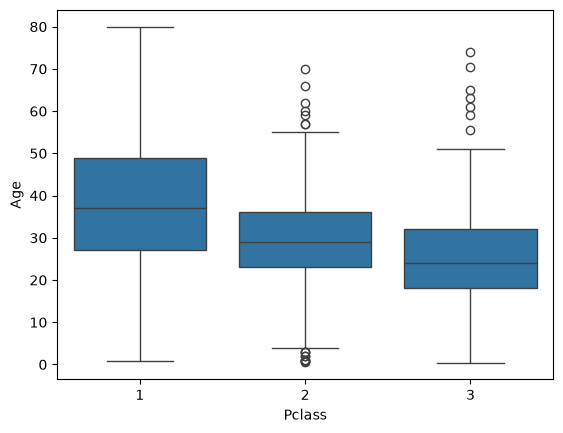

In [8]:
sns.boxplot(x='Pclass', y='Age', data=titan)

In [11]:
# Imputation: Method used for substituting missing data with a different value.

In [10]:
# Imputation Function
def impute_age(cols):
    age=cols[0]
    Pclass=cols[1]
    if pd.isnull(age):
        if Pclass==1:
            return 37
        elif Pclass==2:
            return 29
        else:
            return 24
    else:
        return age

In [ ]:
titan['Age']=titan[['Age','Pclass']].apply(impute_age, axis=1)

KeyError: 0

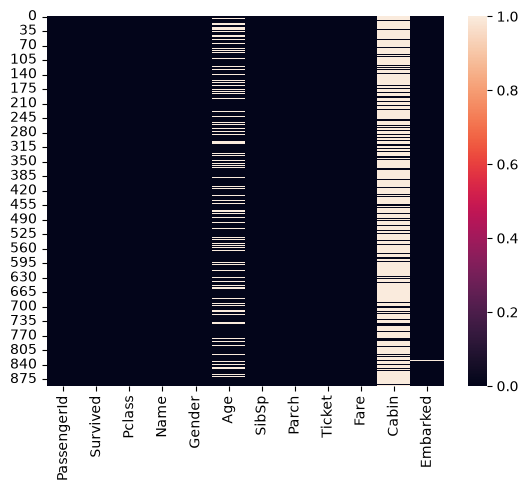

In [13]:
sns.heatmap(titan.isnull())
plt.show()

In [21]:
# Remove dummies, Encoded categorical variable
gender=pd.get_dummies(titan['Gender'], drop_first=True, dtype=int)

In [20]:
embark=pd.get_dummies(titan['Embarked'], drop_first=True, dtype=int)

In [24]:
titan.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Gender', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'male', 'Q', 'S',
       'male', 'Q', 'S'],
      dtype='str')

In [26]:
titan.drop(['PassengerId', 'Cabin', 'Embarked', 'Ticket', 'Gender'], inplace=True, axis=1)

In [27]:
titan.head()

,Survived,Pclass,Name,Age,SibSp,Parch,Fare,male,Q,S,male,Q,S
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,7.2500,True,False,True,1,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,71.2833,False,False,False,0,0,0
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,7.9250,False,False,True,0,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,53.1000,False,False,True,0,0,1
4,0,3,"Allen, Mr. William Henry",35.0,0,0,8.0500,True,False,True,1,0,1


In [22]:
# Merge encoded features:
titan=pd.concat([titan, gender, embark], axis=1)

In [23]:
titan.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,male,Q,S,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,True,False,True,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False,False,False,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,False,True,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False,False,True,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,True,False,True,1,0,1


In [32]:
# Split Feature/target
x = titan.drop('Survived', axis=1)

In [33]:
x

,Pclass,Name,Age,SibSp,Parch,Fare,male,Q,S,male,Q,S
0,3,"Braund, Mr. Owen Harris",22.0,1,0,7.2500,True,False,True,1,0,1
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,71.2833,False,False,False,0,0,0
2,3,"Heikkinen, Miss. Laina",26.0,0,0,7.9250,False,False,True,0,0,1
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,53.1000,False,False,True,0,0,1
4,3,"Allen, Mr. William Henry",35.0,0,0,8.0500,True,False,True,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,"Montvila, Rev. Juozas",27.0,0,0,13.0000,True,False,True,1,0,1
887,1,"Graham, Miss. Margaret Edith",19.0,0,0,30.0000,False,False,True,0,0,1
888,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,23.4500,False,False,True,0,0,1
889,1,"Behr, Mr. Karl Howell",26.0,0,0,30.0000,True,False,False,1,0,0


In [31]:
y = titan['Survived']

In [34]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64